In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Read csv file with parse_dates to notify dealing with dates and index.freq MS to notify of monthly data
df =pd.read_csv('/content/drive/MyDrive/Projects/LSTM/monthly_milk_production.csv',index_col='Date',parse_dates=True)
df.index.freq = 'MS'

In [4]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [39]:
df.tail()

,Production
Date,
1975-08-01,858
1975-09-01,817
1975-10-01,827
1975-11-01,797
1975-12-01,843


In [36]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [38]:
df.shape

(168, 1)

<Axes: xlabel='Date'>

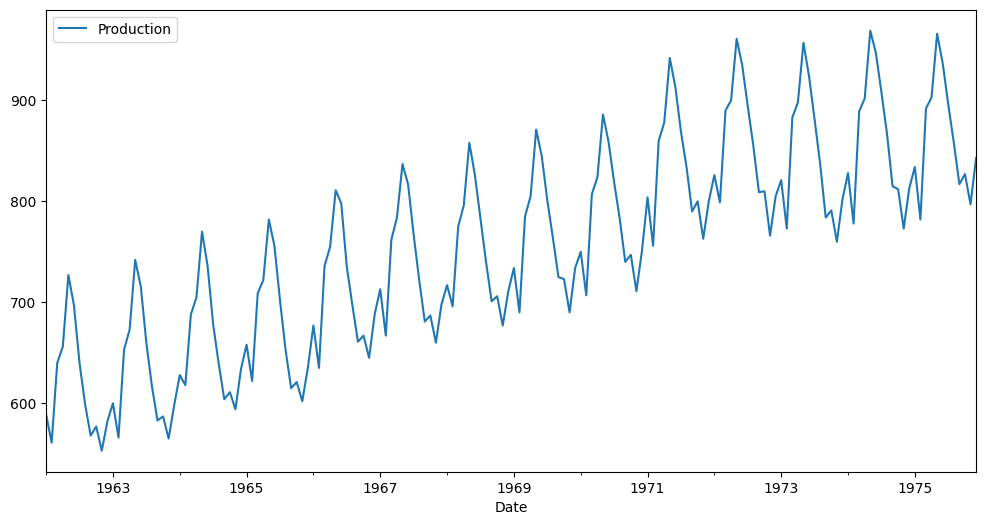

In [5]:
# Plot to visualize seasonality
df.plot(figsize=(12,6))

In [6]:
!pip install --upgrade --no-deps statsmodels

In [7]:
# In order to decompose parts of data series
from statsmodels.tsa.seasonal import seasonal_decompose

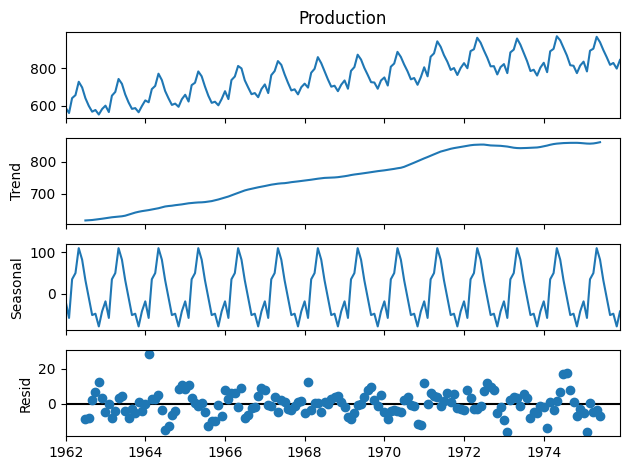

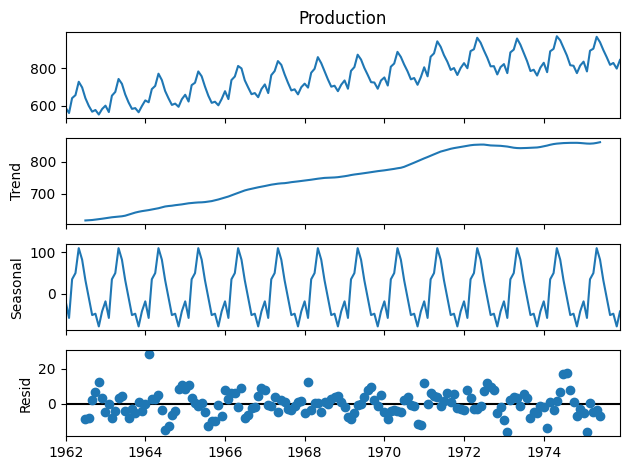

In [8]:
# Chose column to decomposse
results = seasonal_decompose(df['Production'])
results.plot()

In [9]:
len(df)

168

In [10]:
# Use the last 12 months to test data and rest to train data
train = df.iloc[:156]
test = df.iloc[156:]

In [11]:
# Use min max scaler to convert dataset values to a range of 0 to 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [12]:
df.head(),df.tail()

(            Production
 Date                  
 1962-01-01         589
 1962-02-01         561
 1962-03-01         640
 1962-04-01         656
 1962-05-01         727,
             Production
 Date                  
 1975-08-01         858
 1975-09-01         817
 1975-10-01         827
 1975-11-01         797
 1975-12-01         843)

In [13]:
# Fit scaler to training set
scaler.fit(train)
# Transform train and test data
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [14]:
# Check the first ten values
scaled_train[:10]

array([[0.08653846],
       [0.01923077],
       [0.20913462],
       [0.24759615],
       [0.41826923],
       [0.34615385],
       [0.20913462],
       [0.11057692],
       [0.03605769],
       [0.05769231]])

In [15]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [16]:
# Define generator to provide 3 month as input and feature as 1 (more if multiple time series)
n_input = 3
n_features = 1
generator = TimeseriesGenerator(scaled_train, scaled_train, length = n_input,batch_size = 1)

In [17]:
# View the first value done by generator
X,y = generator[0]
print(f'Given the Array: \n{X}')
print(f'Predict this y: \n{y}')

Given the Array: 
[[[0.08653846]
  [0.01923077]
  [0.20913462]]]
Predict this y: 
[[0.24759615]]


In [18]:
X.shape

(1, 3, 1)

In [19]:
# The generator takes the y value and uses it to predict next value
X,y = generator[1]
print(f'Given the Array: \n{X}')
print(f'Predict this y: \n{y}')

Given the Array: 
[[[0.01923077]
  [0.20913462]
  [0.24759615]]]
Predict this y: 
[[0.41826923]]


In [20]:
# Now we do it for 12 months
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length = n_input,batch_size = 1)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [22]:
# Define the model
model = Sequential()
# add lstm layer with 100 neurons relu fxn and input shape
model.add(LSTM(100,activation='relu',input_shape=(n_input,n_features)))
# 1 Dense layer to provide output
model.add(Dense(1))
# Compile the two layers
model.compile(optimizer='adam',loss='mse')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# fit the model with the time series generator input and output
model.fit(generator,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


144/144 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0824
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0310
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0219
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0139
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0088
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0044
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0045
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0089
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0036
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0037
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0046
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0032
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0029
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 

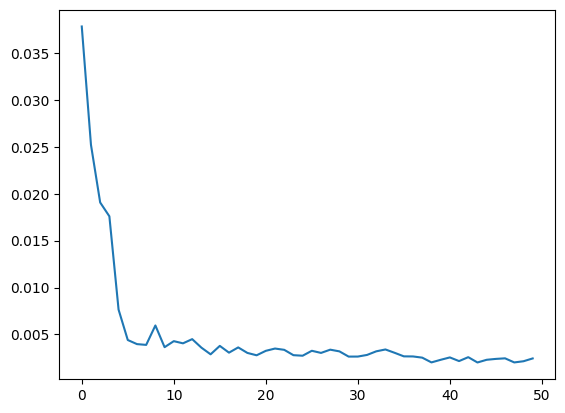

In [25]:
# Plot the loss per epoch
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)
# We can see after how many epochs the loss doesnt significantly decrease

How to make the predictions

For every new pred the model has to take the new prediction and include in the new input


In [26]:
# First 12 month input for first pred
last_train_batch = scaled_train[-12:]

In [27]:
# Reshape it as the array the model has been trained on
last_train_batch = last_train_batch.reshape((1,n_input,n_features))

In [28]:
# Predict the first value of testing set
model.predict(last_train_batch)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step


array([[0.6271331]], dtype=float32)

In [29]:
# Check with the orignal tested value
scaled_test[0]

array([0.67548077])

In [30]:
# Now we start predicting using the testing set
# Empty list of test prediction
test_predictions = []
#Last 12 values of training set and reshape
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1,n_input,n_features))
# Iterate through the testing set
for i in range(len(test)):
  # Get the first prediction value for the first batch using 0 and 1 and so on
  current_pred = model.predict(current_batch)[0]
  # Append the prediction into the empty array to store it
  test_predictions.append(current_pred)
  # Use the prediction to update the batch and remove first value using 1:
  current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [31]:
test_predictions

[array([0.6271331], dtype=float32),
 array([0.5967942], dtype=float32),
 array([0.7497213], dtype=float32),
 array([0.8011673], dtype=float32),
 array([0.8866008], dtype=float32),
 array([0.8762705], dtype=float32),
 array([0.8251426], dtype=float32),
 array([0.74974924], dtype=float32),
 array([0.65068114], dtype=float32),
 array([0.613265], dtype=float32),
 array([0.5581753], dtype=float32),
 array([0.5960886], dtype=float32)]

In [32]:
# Since the predictions are scaled we inverse transform it
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[813.88735771],
       [801.26638222],
       [864.88405609],
       [886.28560066],
       [921.82592964],
       [917.52851677],
       [896.25933075],
       [864.8956852 ],
       [823.68335342],
       [808.11823082],
       [785.20093536],
       [800.97285271]])

In [33]:
# Now append it into the original test set
test['Predictions'] = true_predictions

/tmp/ipython-input-1950080089.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


<Axes: xlabel='Date'>

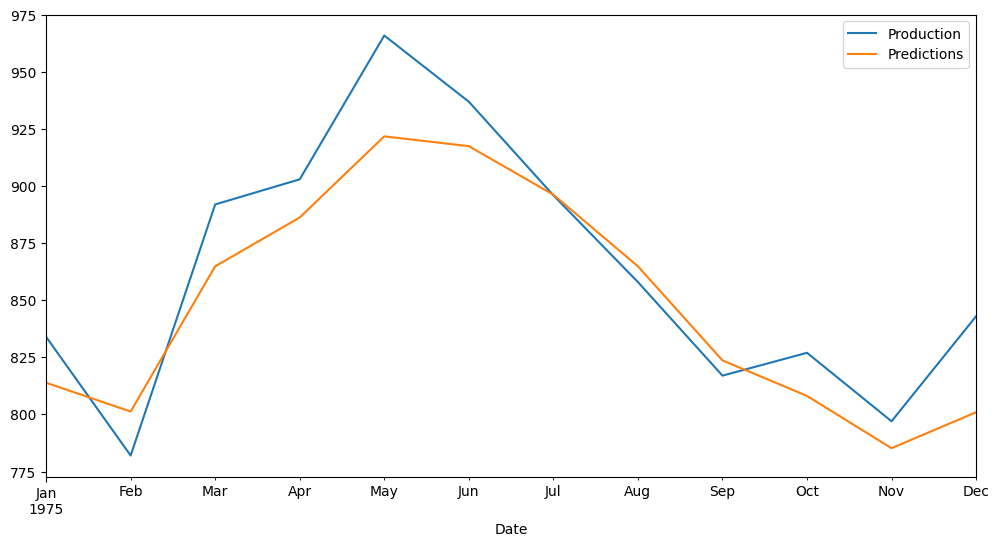

In [34]:
test.plot(figsize=(12,6))

In [35]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(test['Production'],test['Predictions']))
print(rmse)

23.229201731643286


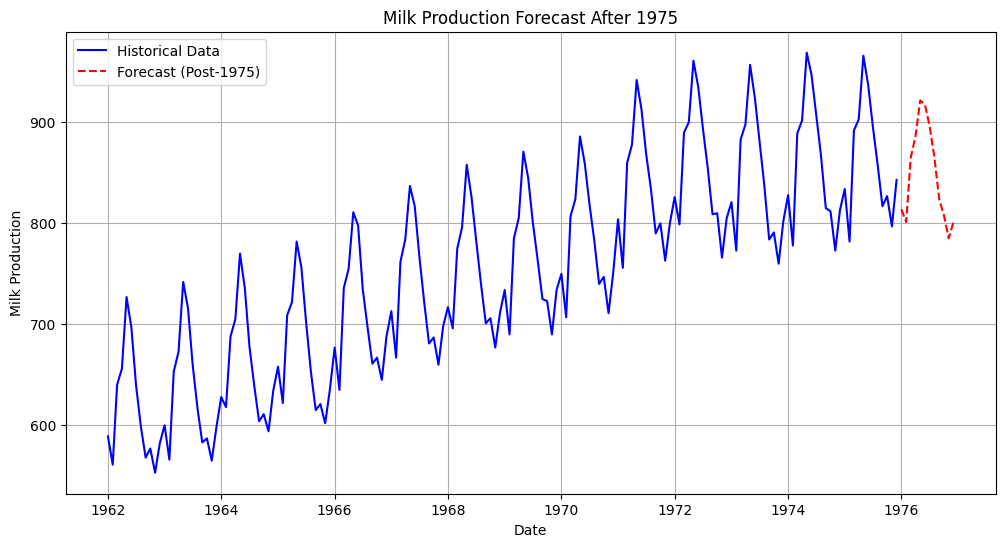

In [53]:

# === Forecast Future Milk Production ===

future_months = 12  # predict next 12 months
n_input = 12  # last 12 months

# Use the final training portion for forecasting
last_sequence = scaled_train[-n_input:]
input_seq = last_sequence.reshape(1, n_input, 1)

# Predict future months iteratively
future_predictions = []
for i in range(future_months):
    pred = model.predict(input_seq, verbose=0)[0]
    future_predictions.append(pred)
    # ✅ reshape pred before appending to keep dimensions consistent
    input_seq = np.append(input_seq[:, 1:, :], [[pred]], axis=1)

# Inverse scale predictions to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create variable for last known date
last_date = df.index[-1]

# Use it to create future dates
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                             periods=future_months, freq='MS')

# Build forecast DataFrame
future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Production': future_predictions.flatten()
})
future_df.set_index('Date', inplace=True)

# === Plot Historical + Forecast ===
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Production'], label='Historical Data', color='blue')
plt.plot(future_df.index, future_df['Predicted_Production'],
         label='Forecast (Post-1975)', color='red', linestyle='--')
plt.title('Milk Production Forecast After 1975')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()


In [54]:

# Display forecasted values
future_df

,Predicted_Production
Date,
1976-01-01,813.887329
1976-02-01,801.266357
1976-03-01,864.884033
1976-04-01,886.285522
1976-05-01,921.825867
1976-06-01,917.528503
1976-07-01,896.259277
1976-08-01,864.895630
1976-09-01,823.683350
